# Loan Default Prediction - EDA

This notebook explores the credit risk dataset.
The goal is to understand the variables, check data quality, and identify patterns linked to loan default.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/credit_risk_dataset.csv")
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Dataset overview

In this section, I check the size of the dataset, the column types, and whether there are missing values.
This helps confirm that the data is usable before modeling.


In [6]:
print(df.shape)
df.info()
df.isnull().sum()


(32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Target variable

Here I look at the distribution of the target variable `loan_status`.
This shows whether the classes are balanced or imbalanced.


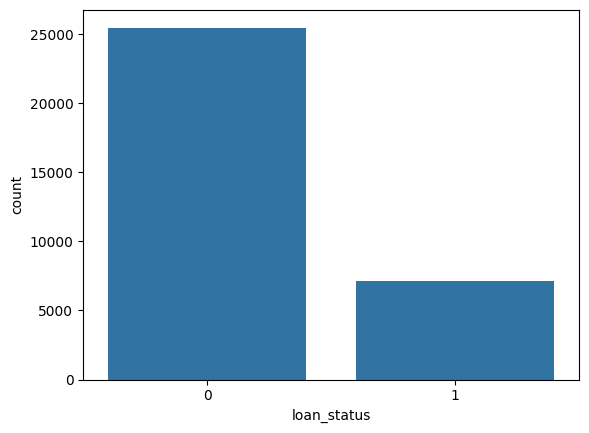

In [8]:
df["loan_status"].value_counts()
sns.countplot(x="loan_status", data=df)
plt.show()


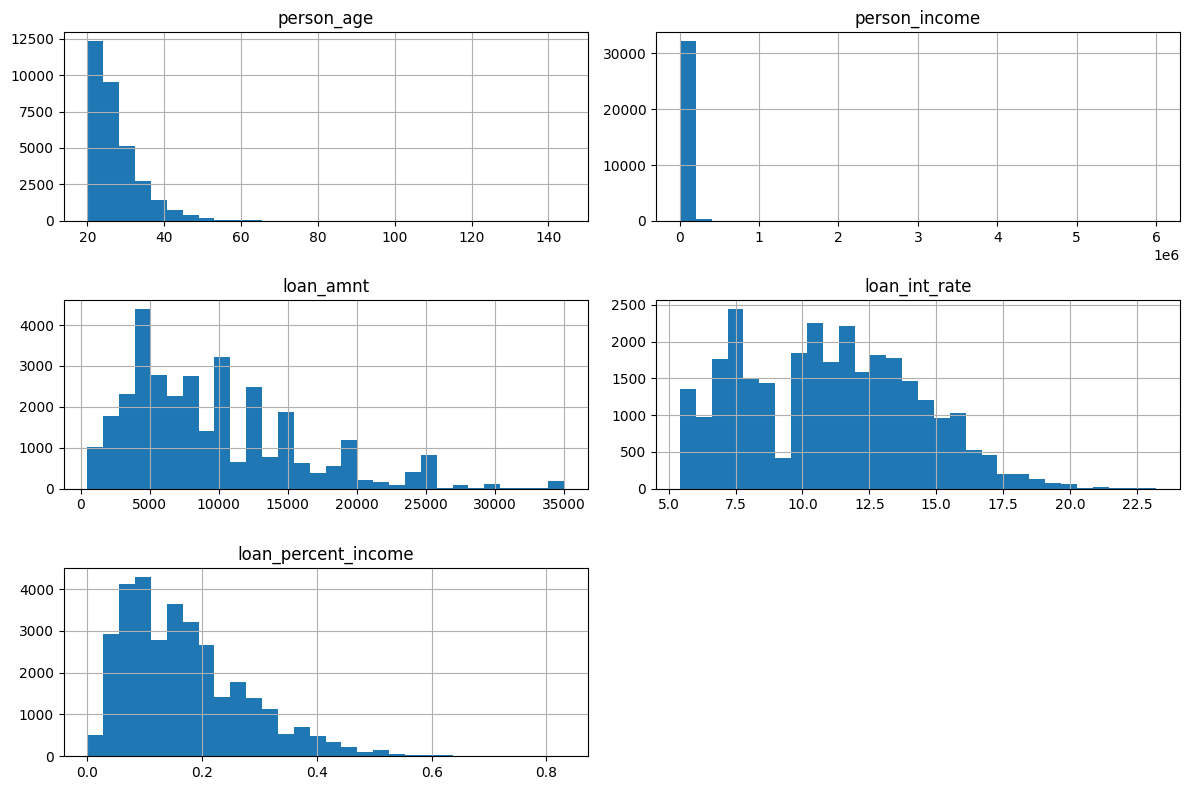

In [9]:
num_cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]
df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


## Relationships with default

These charts help compare a few important variables with the target.
I want to see whether default cases tend to have different income, loan amount, or interest rates.


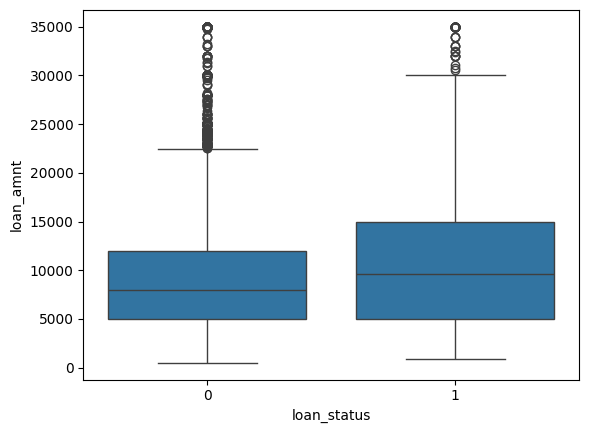

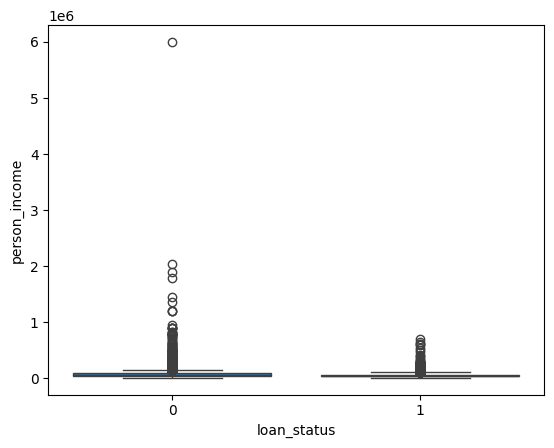

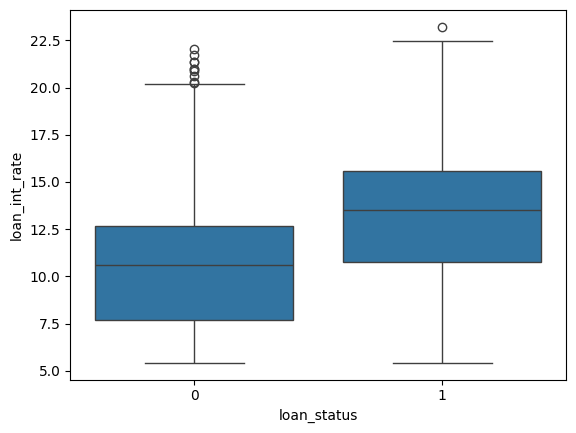

In [11]:
sns.boxplot(x="loan_status", y="loan_amnt", data=df)
plt.show()

sns.boxplot(x="loan_status", y="person_income", data=df)
plt.show()

sns.boxplot(x="loan_status", y="loan_int_rate", data=df)
plt.show()


## Correlation matrix

This heatmap shows the correlations between the numerical variables.
It helps identify which features move together and which ones may be related to loan default.


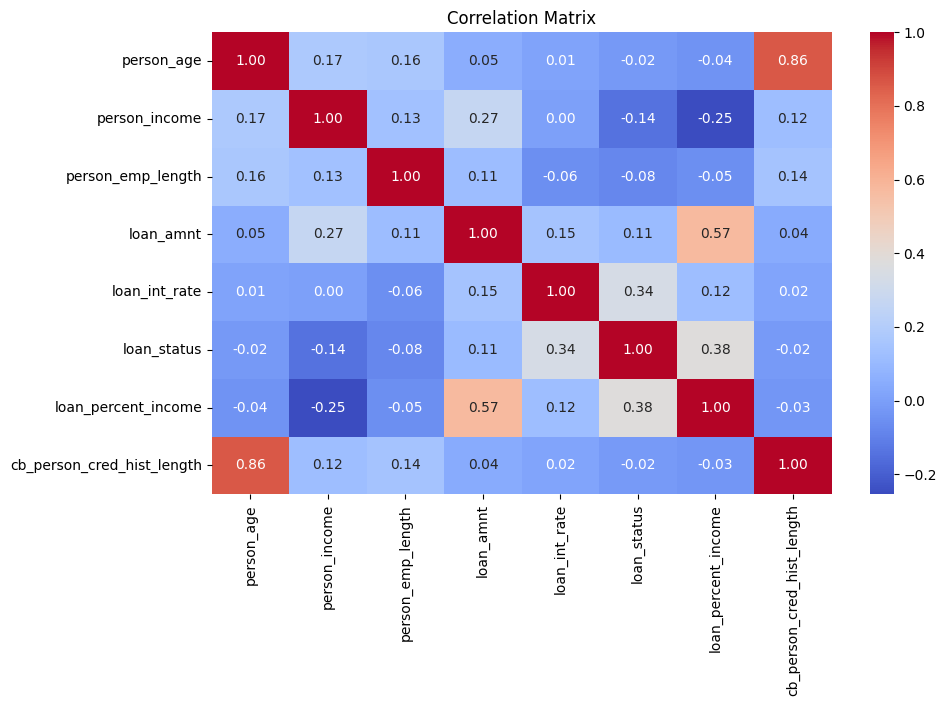

In [12]:
plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


## Key observations

- Missing values and unusual values should be cleaned before training.
- Some numerical features seem to differ between default and non-default cases.
- The target distribution should be considered during model evaluation.
